In [1]:
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
protein_localization = np.load( path + 'protein_localization_dataset.npz')

In [3]:
investigate_dataset(protein_localization)

['X', 'y', 'genes']

Array shapes:
X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(protein_localization['X'], protein_localization['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (9769, 2048)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 65.05%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, protein_localization['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856813,-3.787114,17.809591,9.046370,-4.547431,1.069067,-10.572732,-3.584089,-7.779922,4.624211,...,0.693947,-0.184750,0.331054,0.800883,1.298605,-0.230691,1.602828,0.267513,1.036261,-1.286870
FGR,-10.732224,16.028650,-5.620882,-0.390539,0.571434,-7.164531,-3.195427,0.394462,5.180070,1.700020,...,-0.306140,0.258773,-0.632662,-0.079399,0.097674,-0.289472,0.737982,-0.447546,-0.539607,-0.101729
CFH,7.006835,23.785250,-7.231869,9.518272,5.971798,5.527226,2.497058,-2.941137,-10.176291,6.325774,...,0.964135,0.641253,-0.571630,-0.406045,1.188623,-0.039559,0.157100,0.787240,0.519824,-0.150199
GCLC,3.741436,16.818712,-5.728393,10.611536,1.751319,1.134353,0.392579,2.120315,-4.206432,-1.344817,...,-0.804735,-0.320456,-1.090866,-0.929744,0.507243,1.198914,-0.740625,0.778030,0.560402,-0.903163
NFYA,16.261374,-2.448946,11.577325,-1.681747,-6.333714,6.194884,9.165541,2.846326,6.783356,-1.467644,...,1.306513,-0.525883,-1.591307,-1.076436,-1.305596,-0.805023,-0.910653,0.843173,-0.096069,0.801969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164513,-0.711311,3.695398,-9.967204,-3.281803,2.940934,5.237956,-5.229363,-4.926597,-3.050543,...,-0.083048,-0.115181,-0.135096,-0.103340,0.206227,-0.136678,0.192141,0.076693,0.225253,0.164264
H2AC19,-16.295755,-2.631291,-1.827565,-9.977573,-2.928698,5.729858,-1.167989,-5.806090,-4.658285,-2.984162,...,0.197045,0.158261,0.185541,-0.372778,0.028438,-0.127034,0.263654,-0.268504,-0.156575,0.014729
ENSG00000289346,9.783033,15.400035,-5.534132,8.447064,9.951524,11.424295,5.758761,-8.421936,-7.163840,1.605415,...,-0.171913,-0.143657,-0.445235,-0.712847,1.320176,-1.429221,-0.475660,1.819759,-0.646574,-0.024262


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856813,-3.787114,17.809591,9.046370,-4.547431,1.069067,-10.572732,-3.584089,-7.779922,4.624211,...,0.693947,-0.184750,0.331054,0.800883,1.298605,-0.230691,1.602828,0.267513,1.036261,-1.286870
FGR,-10.732224,16.028650,-5.620882,-0.390539,0.571434,-7.164531,-3.195427,0.394462,5.180070,1.700020,...,-0.306140,0.258773,-0.632662,-0.079399,0.097674,-0.289472,0.737982,-0.447546,-0.539607,-0.101729
CFH,7.006835,23.785250,-7.231869,9.518272,5.971798,5.527226,2.497058,-2.941137,-10.176291,6.325774,...,0.964135,0.641253,-0.571630,-0.406045,1.188623,-0.039559,0.157100,0.787240,0.519824,-0.150199
GCLC,3.741436,16.818712,-5.728393,10.611536,1.751319,1.134353,0.392579,2.120315,-4.206432,-1.344817,...,-0.804735,-0.320456,-1.090866,-0.929744,0.507243,1.198914,-0.740625,0.778030,0.560402,-0.903163
NFYA,16.261374,-2.448946,11.577325,-1.681747,-6.333714,6.194884,9.165541,2.846326,6.783356,-1.467644,...,1.306513,-0.525883,-1.591307,-1.076436,-1.305596,-0.805023,-0.910653,0.843173,-0.096069,0.801969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164513,-0.711311,3.695398,-9.967204,-3.281803,2.940934,5.237956,-5.229363,-4.926597,-3.050543,...,-0.083048,-0.115181,-0.135096,-0.103340,0.206227,-0.136678,0.192141,0.076693,0.225253,0.164264
H2AC19,-16.295755,-2.631291,-1.827565,-9.977573,-2.928698,5.729858,-1.167989,-5.806090,-4.658285,-2.984162,...,0.197045,0.158261,0.185541,-0.372778,0.028438,-0.127034,0.263654,-0.268504,-0.156575,0.014729
ENSG00000289346,9.783033,15.400035,-5.534132,8.447064,9.951524,11.424295,5.758761,-8.421936,-7.163840,1.605415,...,-0.171913,-0.143657,-0.445235,-0.712847,1.320176,-1.429221,-0.475660,1.819759,-0.646574,-0.024262


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732224,16.028650,-5.620882,-0.390539,0.571434,-7.164531,-3.195427,0.394462,5.180070,1.700020,...,0.097674,-0.289472,0.737982,-0.447546,-0.539607,-0.101729,False,False,False,False
CFH,7.006835,23.785250,-7.231869,9.518272,5.971798,5.527226,2.497058,-2.941137,-10.176291,6.325774,...,1.188623,-0.039559,0.157100,0.787240,0.519824,-0.150199,False,False,False,False
GCLC,3.741436,16.818712,-5.728393,10.611536,1.751319,1.134353,0.392579,2.120315,-4.206432,-1.344817,...,0.507243,1.198914,-0.740625,0.778030,0.560402,-0.903163,False,False,False,False
NFYA,16.261374,-2.448946,11.577325,-1.681747,-6.333714,6.194884,9.165541,2.846326,6.783356,-1.467644,...,-1.305596,-0.805023,-0.910653,0.843173,-0.096069,0.801969,False,False,False,False
NIPAL3,12.457914,12.927099,-4.907890,4.092901,-9.950999,0.877897,-0.439547,-0.215892,5.599607,-2.671800,...,0.534984,0.520727,-0.355066,-1.534431,-0.008131,-0.364544,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513517,-20.623869,-19.248234,-18.139862,2.920054,-19.268681,9.507445,3.320702,-7.482670,1.156771,...,-0.371426,-0.072926,-0.454994,-1.237228,-0.821740,0.969793,False,False,False,False
MRM1,-12.605591,11.342200,-3.682096,-3.019349,-2.138480,-6.590556,-3.055246,-0.243641,4.935575,-0.558495,...,0.400279,0.182700,0.706844,-0.323971,0.784011,-1.278055,False,False,False,False
MRPL45,-14.170582,-2.043021,9.330470,-6.103004,0.370753,1.467921,8.085640,-0.145325,-0.400819,1.473241,...,0.336079,0.815506,-0.940678,0.209792,0.493922,-0.384735,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

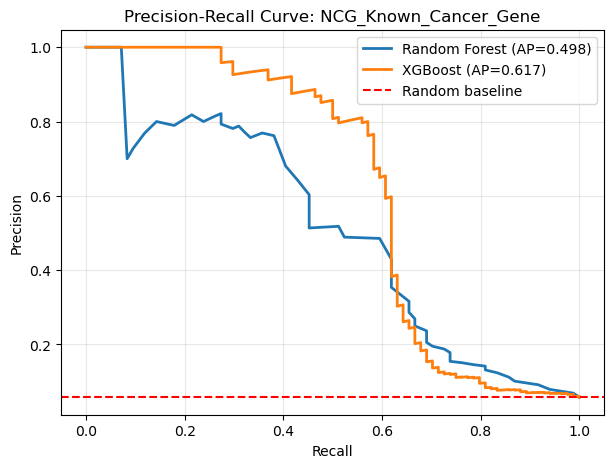

Random Forest - auPRC: 0.498
XGBoost - auPRC: 0.617



In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

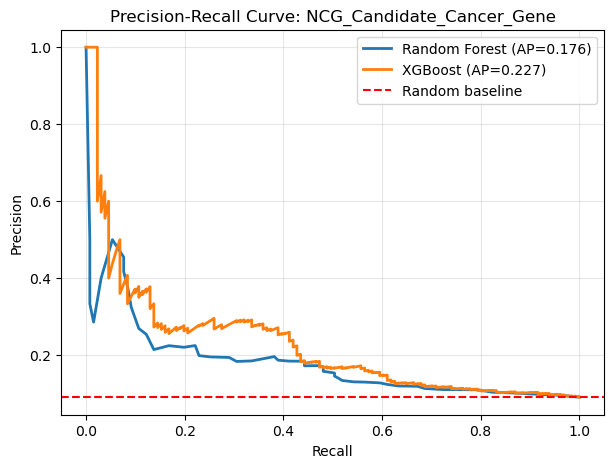

Random Forest - auPRC: 0.176
XGBoost - auPRC: 0.227



In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

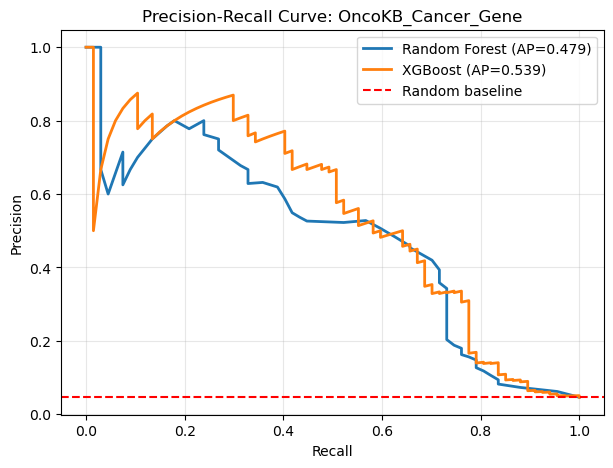

Random Forest - auPRC: 0.479
XGBoost - auPRC: 0.539



In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

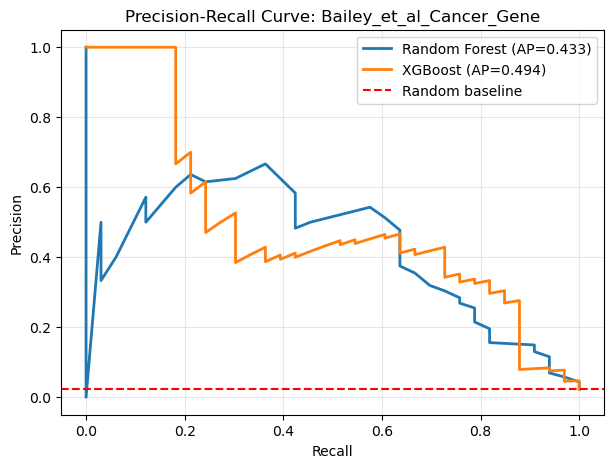

Random Forest - auPRC: 0.433
XGBoost - auPRC: 0.494



In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')